## artificial neural network classifier 
After preprocessing, every match becomes a numerical vector.

Conceptually, the network receives inputs such as:

Ranking difference
Points difference
Previous win-rate difference
Recent-form difference
Surface win-rate difference
Head-to-head information
Tournament surface
Tournament round

The network contains:

Input layer → Hidden layer or layers → Output

Each hidden neuron calculates a weighted combination of its inputs, adds a bias and applies an activation function. During training, the weights are repeatedly adjusted to reduce classification error.

The goal of this notebook is to use an Artificial Neural Network
to predict whether Player 1 wins the match.

The network receives the numerical pre-match features created in the
previous notebooks. The output is a probability between 0 and 1.

A value close to 1 means that the network expects Player 1 to win,
while a value close to 0 means that it expects Player 2 to win.

In [1]:
from pathlib import Path 

import numpy as np 
import pandas as pd 
import tensorflow as tf

import matplotlib.pyplot as plt 

from sklearn.preprocessing import StandardScaler 

import sys
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
from src.preprocessing import (
    fit_preprocessor,
    transform_data,
    categorical_features,
    numeric_features
)

from src.temporal_cv import (
    create_temporal_folds,
    validation_years
)

from src.evaluation import (
    evaluate_model
)

from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score,
    log_loss,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation 
from tensorflow.keras import Input 
from tensorflow.keras import optimizers

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = (
    PROCESSED_DATA_DIR / "feature_split_matches.csv"
)

matches = pd.read_csv(
    input_file, parse_dates = ["Date"]
)

matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)
print(matches["DataSplit"].value_counts())


Dataset shape: (26536, 53)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


In [4]:
## create copies of the sets 
train_data = matches.loc[
    matches["DataSplit"] == "Training"
].copy()

validation_data = matches.loc[
    matches["DataSplit"] == "Validation"
].copy()

test_data = matches.loc[
    matches["DataSplit"] == "Test"
].copy()

## check the periods
print(
    "Training:", 
    train_data["Date"].min(),
    "-",
    train_data["Date"].max()
)

print(
    "Validating:", 
    validation_data["Date"].min(),
    "-",
    validation_data["Date"].max()
)

print(
    "Testing:", 
    test_data["Date"].min(),
    "-",
    test_data["Date"].max()
)


Training: 2015-01-05 00:00:00 - 2022-11-20 00:00:00
Validating: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Testing: 2024-01-01 00:00:00 - 2025-11-16 00:00:00


In [5]:
assert(
    train_data["Date"].max() < validation_data["Date"].min()
)

assert(
    validation_data["Date"].max() < test_data["Date"].min()
)

print("Chronological order is maintained.")

Chronological order is maintained.


In [6]:
# The feature lists are imported from preprocessing.py.
# This ensures that all prediction models use
# exactly the same starting feature set.

print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Raw features:",
    len(numeric_features) + len(categorical_features)
)


Numerical features: 30
Categorical features: 5
Raw features: 35


In [7]:
##create temporal cross-validation folds for the training set
temporal_folds= create_temporal_folds(
    train_data,
    validation_years = validation_years
)

print(
    "Number of temporal folds created:", 
    len(temporal_folds)
)

pd.DataFrame(temporal_folds)

Number of temporal folds created: 4


,Fold,TrainingMatches,ValidationMatches,TrainingStartYear,TrainingEndYear,ValidationYear
0,1,10135,2497,2015,2018,2019
1,2,12632,1231,2015,2019,2020
2,3,13863,2402,2015,2020,2021
3,4,16265,2545,2015,2021,2022


In [8]:
## create input and outputs
(
    numeric_medians,
    categorical_modes,
    one_hot_encoder
) = fit_preprocessor(
    train_data
)

X_train = transform_data(
    train_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

X_validation = transform_data(
    validation_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

# Target:
# 1 = Player 1 wins
# 0 = Player 2 wins
y_train = train_data["Player1Won"].to_numpy()
y_validation = validation_data["Player1Won"].to_numpy()


In [9]:
# After preprocessing we expect:
# 30 numerical features
# + 20 one-hot encoded categorical features
# = 50 final model features

print("Training X:", X_train.shape)
print("Training y:", y_train.shape)

print("Validating X:", X_validation.shape)
print("Validating y:", y_validation.shape)

assert X_train.shape[1] == 50
assert X_validation.shape[1] == 50

assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0

print(
    "ANN preprocessing check passed."
)

Training X: (18810, 50)
Training y: (18810,)
Validating X: (2607, 50)
Validating y: (2607,)
ANN preprocessing check passed.


The ANN is trained on standardized numerical inputs.

`fit_transform` is used only on the training set.  
For validation I use only `transform`, so the validation distribution is not used to fit the scaler.

In [10]:
# standardize the input 
# One-hot encoded features are already binary (0/1).
# Standardize only the original numerical features.

normalizer = StandardScaler()

X_train[numeric_features] = normalizer.fit_transform(X_train[numeric_features])
X_validation[numeric_features] = normalizer.transform(X_validation[numeric_features])

# Numerical training variables should now
# have mean approximately 0 and standard deviation approximately 1.
X_train[numeric_features].describe().T.head(10)


,count,mean,std,min,25%,50%,75%,max
Player1Rank,18810.0,6.648353e-17,1.000027,-0.793058,-0.538951,-0.229603,0.190227,22.905215
Player2Rank,18810.0,7.101650e-17,1.000027,-0.786692,-0.525388,-0.220532,0.182312,19.028912
Player1Points,18810.0,1.510989e-18,1.000027,-0.830961,-0.491406,-0.329513,0.040528,8.077883
Player2Points,18810.0,-4.381869e-17,1.000027,-0.832648,-0.486083,-0.320054,0.035109,8.188260
Player1MatchesBefore,18810.0,0.000000e+00,1.000027,-1.139764,-0.818762,-0.276378,0.598076,3.841308
Player2MatchesBefore,18810.0,9.670332e-17,1.000027,-1.125410,-0.816726,-0.287553,0.572353,3.846609
ExperienceDifference,18810.0,3.777473e-18,1.000027,-3.920863,-0.482052,0.001086,0.484225,3.979876
Player1WinRateBefore,18810.0,2.750001e-16,1.000027,-3.317998,-0.637339,-0.106858,0.635232,3.222076
Player2WinRateBefore,18810.0,-6.882556e-16,1.000027,-3.430939,-0.623094,-0.099114,0.627179,3.245129
WinRateDifference,18810.0,-4.532968e-18,1.000027,-3.881126,-0.654353,-0.006439,0.652866,4.210699


In [11]:
# Convert the final DataFrames to NumPy arrays
# before giving them to TensorFlow.

X_train = X_train.to_numpy(dtype=np.float32)
X_validation = X_validation.to_numpy(dtype=np.float32)

print("Final ANN Training matrix:", X_train.shape)
print("Final ANN Validation matrix:", X_validation.shape)

Final ANN Training matrix: (18810, 50)
Final ANN Validation matrix: (2607, 50)


In [12]:
# create first neural network 

num_instances, num_features = X_train.shape 

print("Number of training matches:", num_instances)
print("Number of input features:", num_features)

Number of training matches: 18810
Number of input features: 50


Input features → hidden layer(s) → sigmoid output

This is a binary classification problem, so the sigmoid output represents the estimated probability that Player 1 wins.  
The predictive ANN lesson uses sigmoid with `binary_crossentropy` for binary classification.

The project requires parameter tuning. I keep the search small and manual, like the experiments in the lessons.

I vary:
- hidden-layer size
- number of hidden layers
- activation
- learning rate
- number of epochs

In [13]:
def build_model(
    input_features,
    hidden_layers,
    hidden_activation,
    learning_rate
):
    """
    Build and compile an Artificial Neural Network.

    input_features:
        Number of input variables received by the ANN.

    hidden_layers:
        List containing the number of neurons
        in each hidden layer.

    hidden_activation:
        Activation function used by hidden layers.

    learning_rate:
        Learning rate used by Adam.
    """
    #initialize network 
    current_model = Sequential()
    
    #input 
    current_model.add(Input(shape=(input_features,)))
    
    #hidden layer 
    # Example:
    # hidden_layers = [32, 16]
    #
    # creates two hidden layers:
    # 32 neurons -> 16 neurons.
    for number_of_neurons in hidden_layers: 
        
        current_model.add(Dense(number_of_neurons))
        current_model.add(Activation(hidden_activation))
        
    # Binary output:
    # probability that Player 1 wins.
    current_model.add(Dense(1))
    current_model.add(Activation("sigmoid"))
    
    #finalize the network 
    current_model.compile(
        optimizer=optimizers.Adam(
            learning_rate=learning_rate
        ), 
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return current_model

In [14]:
configurations = [
    {
        "name" : "ANN 8 sigmoid",
        "hidden_layers": [8], 
        "activation": "sigmoid", 
        "learning_rate": 0.01, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 16 relu",
        "hidden_layers": [16], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    },
    
    {
        "name": "ANN 32 relu", 
        "hidden_layers": [32], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 32-16 relu", 
        "hidden_layers": [32, 16], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 32-16 slow", 
        "hidden_layers": [32, 16], 
        "activation": "relu",
        "learning_rate": 0.0005, 
        "epochs": 100
    }
    
]

In [15]:
# One row will be stored for every:
# configuration × temporal fold
# With 5 configurations and 4 folds,
# we expect 20 rows.

cv_results = []

for configuration in configurations: 
    
    print("\nTesting ANN model:", configuration["name"])
    
    # Evaluate the current ANN configuration
    # on all four temporal folds.

    for fold in temporal_folds:

        fold_number = fold["Fold"]
        validation_year = fold["ValidationYear"]


        print(
            "  Fold",
            fold_number,
            "- validation year:",
            validation_year
        )
        
        #recerate current training and validation sets for the current fold

        fold_train = train_data.loc[
            train_data["Date"].dt.year < validation_year
        ].copy()
        
        fold_validation = train_data.loc[
            train_data["Date"].dt.year == validation_year
        ].copy()
        
        #learn medians, modes and one-hot encoder from the current fold_train
        (
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        ) = fit_preprocessor(
            fold_train
        )
        
        #transfrorm the current fold_train and fold_validation sets
        X_fold_train = transform_data(
            fold_train,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )


        X_fold_validation = transform_data(
            fold_validation,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )
        
         # Targets for this fold.

        y_fold_train = (
            fold_train["Player1Won"].to_numpy()
        )

        y_fold_validation = (
            fold_validation["Player1Won"].to_numpy()
        )
        
        # A NEW scaler is fitted for every temporal fold.
        # fit only on fold training,
        # never on fold validation.
        
        fold_scaler = StandardScaler()
        
        #scale only the numerical features, not the one-hot encoded categorical features
        X_fold_train[numeric_features] = (
            fold_scaler.fit_transform(
                X_fold_train[numeric_features]
            )
        )
        
        X_fold_validation[numeric_features] = (
            fold_scaler.transform(
                X_fold_validation[numeric_features]
            )
        ) 
        
        X_fold_train = X_fold_train.to_numpy(dtype=np.float32)
        X_fold_validation = X_fold_validation.to_numpy(dtype=np.float32)  
        
        #build the ANN for the current configuration
        np.random.seed(42)
        tf.random.set_seed(42)


        current_model = build_model(
            input_features=X_fold_train.shape[1],
            hidden_layers=configuration["hidden_layers"],
            hidden_activation=configuration["activation"],
            learning_rate=configuration["learning_rate"]
        )
        
        #train the ANN for the current configuration
        current_model.fit(
            x=X_fold_train,
            y=y_fold_train,
            epochs=configuration["epochs"],
            batch_size=128,
            verbose=0
        ) 
        
        #predict the current fold validation set
        current_fold_probabilities = ( current_model.predict(
                X_fold_validation,
                verbose=0
            ).reshape(-1)
        )
        
        # probability >= 0.5 -> Player 1 wins
        # probability < 0.5  -> Player 2 wins
        current_fold_predictions = (
            current_fold_probabilities >= 0.5
        ).astype(int)
        
        #use common evaluation function to calculate metrics for the current fold
        current_fold_result = evaluate_model(
            y_true=y_fold_validation,
            y_pred=current_fold_predictions,
            model_name=configuration["name"],
            y_probability=current_fold_probabilities
        )
        
        #store the current fold results into dictionary
        current_fold_result = ( current_fold_result.iloc[0].to_dict())
        
        #add info to identify fold
        current_fold_result[
            "Fold"
        ] = fold_number

        current_fold_result[
            "ValidationYear"
        ] = validation_year
        
        current_fold_result[
            "HiddenLayers"
        ] = str(
            configuration["hidden_layers"]
        )

        current_fold_result[
            "Activation"
        ] = configuration[
            "activation"
        ]

        current_fold_result[
            "LearningRate"
        ] = configuration[
            "learning_rate"
        ]

        current_fold_result[
            "Epochs"
        ] = configuration[
            "epochs"
        ]
        
        #store the current fold results into the list of all results
        cv_results.append(current_fold_result)
        


Testing ANN model: ANN 8 sigmoid
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022

Testing ANN model: ANN 16 relu
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022

Testing ANN model: ANN 32 relu
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022

Testing ANN model: ANN 32-16 relu
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022

Testing ANN model: ANN 32-16 slow
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022


In [16]:
ann_cv_results = pd.DataFrame(cv_results)

ann_cv_results 

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss,Fold,ValidationYear,HiddenLayers,Activation,LearningRate,Epochs
0,ANN 8 sigmoid,0.621946,0.621542,0.630551,0.573506,0.600677,0.674551,0.640933,1,2019,[8],sigmoid,0.0100,50
1,ANN 8 sigmoid,0.649066,0.653337,0.713402,0.541471,0.615658,0.707309,0.634998,2,2020,[8],sigmoid,0.0100,50
2,ANN 8 sigmoid,0.627394,0.625781,0.618132,0.585429,0.601336,0.679801,0.641444,3,2021,[8],sigmoid,0.0100,50
3,ANN 8 sigmoid,0.633399,0.633653,0.621068,0.671677,0.645382,0.703877,0.624943,4,2022,[8],sigmoid,0.0100,50
4,ANN 16 relu,0.614738,0.614670,0.612561,0.606624,0.609578,0.675421,0.642064,1,2019,[16],relu,0.0010,50
5,ANN 16 relu,0.653128,0.654951,0.687943,0.607199,0.645054,0.717839,0.615216,2,2020,[16],relu,0.0010,50
6,ANN 16 relu,0.648626,0.647964,0.634699,0.631396,0.633043,0.697727,0.625516,3,2021,[16],relu,0.0010,50
7,ANN 16 relu,0.646758,0.646855,0.639633,0.661392,0.650331,0.707171,0.621411,4,2022,[16],relu,0.0010,50
8,ANN 32 relu,0.616340,0.616151,0.617647,0.593700,0.605437,0.672015,0.643834,1,2019,[32],relu,0.0010,50
9,ANN 32 relu,0.635256,0.638420,0.682692,0.555556,0.612597,0.700062,0.638113,2,2020,[32],relu,0.0010,50


In [17]:
#check that the number of experiments is correct
print("Number of experiments:", ann_cv_results.shape[0])
assert(len(ann_cv_results) == len(configurations) * len(temporal_folds))

Number of experiments: 20


#CALCULATE MEAN OF THE 4 FOLDS#
For each ANN configuration, calculate mean and sd. 

In [18]:
ann_cv_summary = ann_cv_results.groupby("Model", as_index=False).agg(
        MeanAccuracy = ("Accuracy", "mean"),
        StdAccuracy = ("Accuracy", "std"),
        MeanBalancedAccuracy = ("BalancedAccuracy", "mean"),
        MeanF1Score = ("F1", "mean"),
        MeanROC_AUC = ("ROC-AUC", "mean"),
        MeanLogLoss = ("LogLoss", "mean")
)

In [19]:
#prefer configuration with highest avarage temporal-CV accuracy
#ROC-AUC used as tie-breaker
ann_cv_summary = ann_cv_summary.sort_values(
    by=["MeanAccuracy", "MeanROC_AUC"],
    ascending=[False, False]
).reset_index(drop=True)

ann_cv_summary

,Model,MeanAccuracy,StdAccuracy,MeanBalancedAccuracy,MeanF1Score,MeanROC_AUC,MeanLogLoss
0,ANN 16 relu,0.640812,0.017588,0.641110,0.634502,0.699540,0.626052
1,ANN 8 sigmoid,0.632951,0.011717,0.633578,0.615763,0.691385,0.635580
2,ANN 32 relu,0.632558,0.013218,0.633289,0.623057,0.692491,0.634495
3,ANN 32-16 relu,0.625739,0.019618,0.626383,0.612147,0.678669,0.648802
4,ANN 32-16 slow,0.623415,0.012153,0.624357,0.616910,0.675140,0.655472


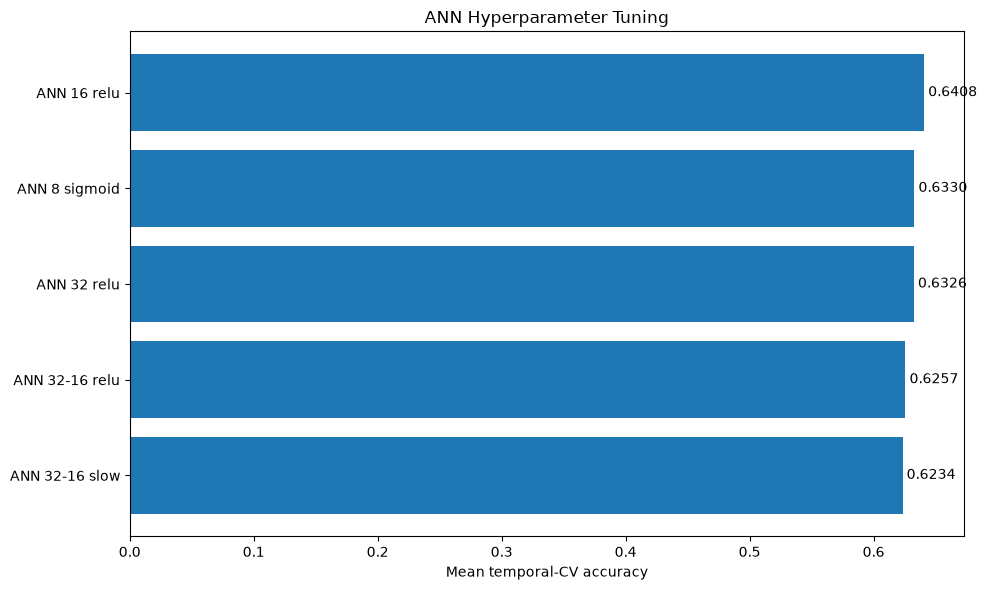

In [20]:
plot_data = (
    ann_cv_summary.sort_values(
        "MeanAccuracy",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data["Model"],
    plot_data["MeanAccuracy"]
)

plt.xlabel("Mean temporal-CV accuracy")

plt.title("ANN Hyperparameter Tuning")

for bar, value in zip(
    bars,
    plot_data["MeanAccuracy"]
):

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [21]:
#store the name of the configuartion with best mean temporal-CV accuracy
best_model_name = (ann_cv_summary.iloc[0]["Model"])
print("Selected ANN from temporal CV:", best_model_name)

Selected ANN from temporal CV: ANN 16 relu


In [22]:
#store and print the complete parameter dictionary of the best model

best_configuration = next(
    configuration
    for configuration in configurations 
    if configuration["name"]== best_model_name
)

best_configuration

{'name': 'ANN 16 relu',
 'hidden_layers': [16],
 'activation': 'relu',
 'learning_rate': 0.001,
 'epochs': 50}

Create a new ANN from scratch. Do not use fold models

In [23]:
np.random.seed(42)
tf.random.set_seed(42)

#build a new model using configuartion chose by temporal CV 
best_model = build_model(
    input_features=X_train.shape[1],
    hidden_layers=best_configuration["hidden_layers"],
    hidden_activation= best_configuration["activation"],
    learning_rate=best_configuration["learning_rate"]
)


In [24]:
#train the selected configuration on all training data: 2015-2022
# 2023=validation set

best_history = best_model.fit(
    x=X_train,
    y=y_train,
    epochs=best_configuration["epochs"],
    batch_size=128,
    validation_data=(X_validation, y_validation),
    verbose=1
)

Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6302 - loss: 0.6408 - val_accuracy: 0.6379 - val_loss: 0.6316
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6533 - loss: 0.6169 - val_accuracy: 0.6448 - val_loss: 0.6239
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6591 - loss: 0.6124 - val_accuracy: 0.6463 - val_loss: 0.6206
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6624 - loss: 0.6100 - val_accuracy: 0.6471 - val_loss: 0.6189
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6640 - loss: 0.6084 - val_accuracy: 0.6521 - val_loss: 0.6178
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6651 - loss: 0.6071 - val_accuracy: 0.6502 - val_loss: 0.6172
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6660 - loss: 0.6060 - val_accuracy: 0.6498 - val_loss: 0.6171
Epoch 8/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6668 - loss: 0.6052 - val_accuracy: 0.

In [25]:
best_validation_probabilities = (
    best_model.predict(
        X_validation, 
        verbose=0
    ).reshape(-1)
)

best_validation_predictions = (
    best_validation_probabilities >= 0.5 
).astype(int)


print(
    classification_report(
        y_validation,
        best_validation_predictions,
        target_names=[
            "Player 2 wins",
            "Player 1 wins"
        ],
        zero_division=0
    )
)


               precision    recall  f1-score   support

Player 2 wins       0.66      0.67      0.67      1368
Player 1 wins       0.63      0.62      0.62      1239

     accuracy                           0.65      2607
    macro avg       0.64      0.64      0.64      2607
 weighted avg       0.65      0.65      0.65      2607



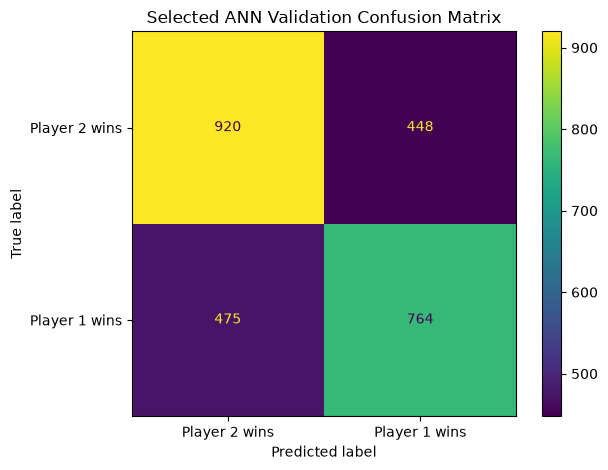

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    best_validation_predictions,
    display_labels=[
        "Player 2 wins",
        "Player 1 wins"
    ],
    values_format="d"
)

plt.title(
    "Selected ANN Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [27]:
#evaluate ann selected on external 2023 validation set
best_ann_results=evaluate_model(
    y_true=y_validation,
    y_pred=best_validation_predictions,
    y_probability=best_validation_probabilities,
    model_name=best_model_name
)

best_ann_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss
0,ANN 16 relu,0.645953,0.64457,0.630363,0.616626,0.623419,0.697835,0.624205


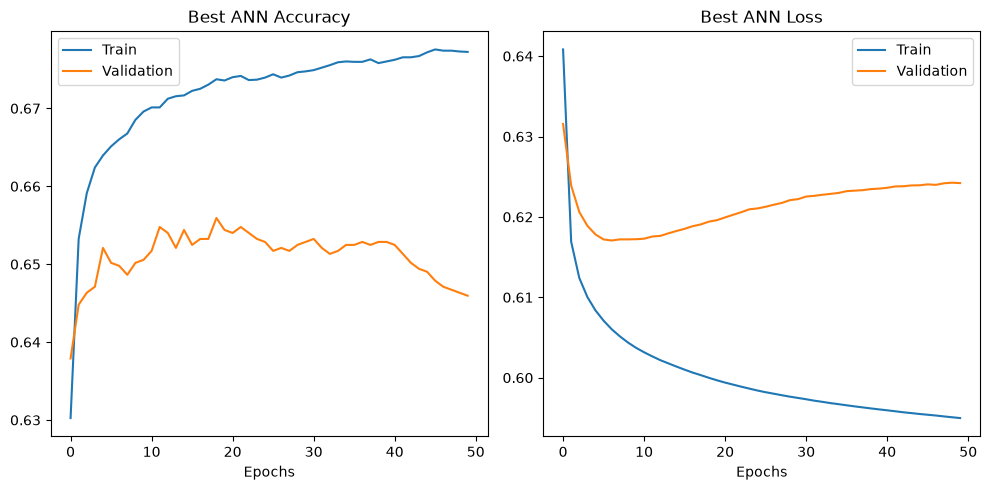

In [28]:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 5)
)

axes[0].plot(best_history.history["accuracy"], label="Train")
axes[0].plot(best_history.history["val_accuracy"], label="Validation")

axes[0].set_title("Best ANN Accuracy")
axes[0].set_xlabel("Epochs")
axes[0].legend()

axes[1].plot(best_history.history["loss"], label="Train")
axes[1].plot(best_history.history["val_loss"], label="Validation")

axes[1].set_title("Best ANN Loss")
axes[1].set_xlabel("Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

In [29]:
# create the folder to save the results 
RESULTS_DIR = Path("../results")
MODELS_DIR = Path("../models")

RESULTS_DIR.mkdir(
    parents = True,
    exist_ok=True
)

MODELS_DIR.mkdir(
    parents=True, 
    exist_ok=True
)

ann_cv_results.to_csv(
    RESULTS_DIR / "ann_cv_fold_results.csv",
    index=False
)

ann_cv_summary.to_csv(
    RESULTS_DIR / "ann_cv_summary.csv",
    index=False
)

best_model.save(
    MODELS_DIR / "best_ann_validation.keras"
)

In [30]:
import joblib 

joblib.dump(normalizer, MODELS_DIR / "ann_scaler.joblib")

ann_preprocessing = {
    "numeric_medians": numeric_medians,
    "categorical_modes": categorical_modes,
    "one_hot_encoder": one_hot_encoder
}

joblib.dump(
    ann_preprocessing,
    MODELS_DIR/"ann_preprocessing.joblib"
)

['..\\models\\ann_preprocessing.joblib']

In [31]:
# final tuning summary 
print("ANN temporal-cv tuning:")

print(ann_cv_summary)


ANN temporal-cv tuning:
            Model  MeanAccuracy  StdAccuracy  MeanBalancedAccuracy  \
0     ANN 16 relu      0.640812     0.017588              0.641110   
1   ANN 8 sigmoid      0.632951     0.011717              0.633578   
2     ANN 32 relu      0.632558     0.013218              0.633289   
3  ANN 32-16 relu      0.625739     0.019618              0.626383   
4  ANN 32-16 slow      0.623415     0.012153              0.624357   

   MeanF1Score  MeanROC_AUC  MeanLogLoss  
0     0.634502     0.699540     0.626052  
1     0.615763     0.691385     0.635580  
2     0.623057     0.692491     0.634495  
3     0.612147     0.678669     0.648802  
4     0.616910     0.675140     0.655472  


In [32]:
print(
    "Selected ANN:",
    best_model_name
)

print("\nExternal 2023 validation:")
print(best_ann_results)


Selected ANN: ANN 16 relu

External 2023 validation:
         Model  Accuracy  BalancedAccuracy  Precision    Recall        F1  \
0  ANN 16 relu  0.645953           0.64457   0.630363  0.616626  0.623419   

    ROC-AUC   LogLoss  
0  0.697835  0.624205  
